Répertoire courant : c:\Users\nidha\Desktop\xai_clinical_prediction\notebooks
project_root trouvé : c:\Users\nidha\Desktop\xai_clinical_prediction

DATA_DIR existe : True
✅ data_clinical_patient.txt
✅ data_mrna_seq_v2_rsem.txt
✅ data_mutations.txt

✅ Tous les fichiers trouvés !
Données cliniques: (1097, 111)
['OTHER_PATIENT_ID', 'PATIENT_ID', 'FORM_COMPLETION_DATE', 'PROSPECTIVE_COLLECTION', 'RETROSPECTIVE_COLLECTION', 'SEX', 'MENOPAUSE_STATUS', 'RACE', 'ETHNICITY', 'HISTORY_OTHER_MALIGNANCY', 'HISTORY_NEOADJUVANT_TRTYN', 'TUMOR_STATUS', 'RADIATION_TREATMENT_ADJUVANT', 'PHARMACEUTICAL_TX_ADJUVANT', 'HISTOLOGICAL_SUBTYPE', 'INITIAL_PATHOLOGIC_DX_YEAR', 'AGE', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT', 'METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER', 'SURGICAL_PROCEDURE_FIRST', 'FIRST_SURGICAL_PROCEDURE_OTHER', 'PATH_MARGIN', 'SURGERY_FOR_POSITIVE_MARGINS', 'SURGERY_FOR_POSITIVE_MARGINS_OTHER', 'MARGIN_STATUS_REEXCISION', 'STAGING_SYSTEM', 'STAGING_SYSTEM_OTHER', 'MICROMET_DETECTION_BY_IHC', '

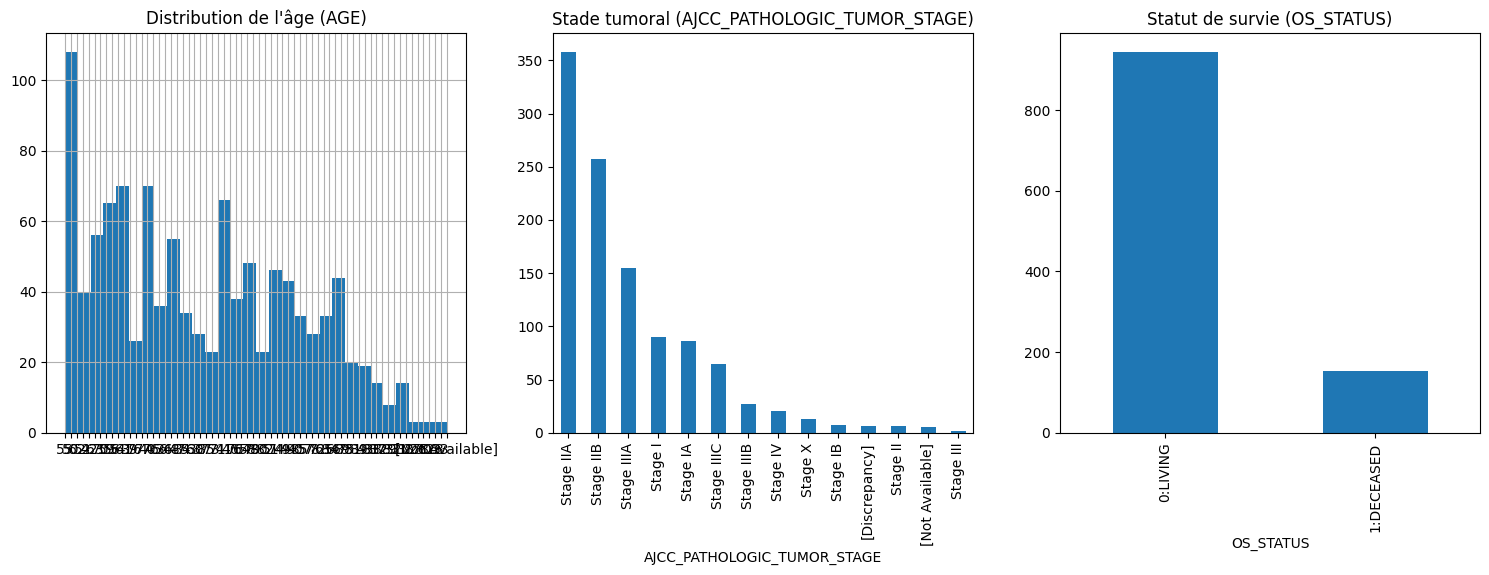

Expression génique: (20531, 1102)
Transposé: (1100, 20531)


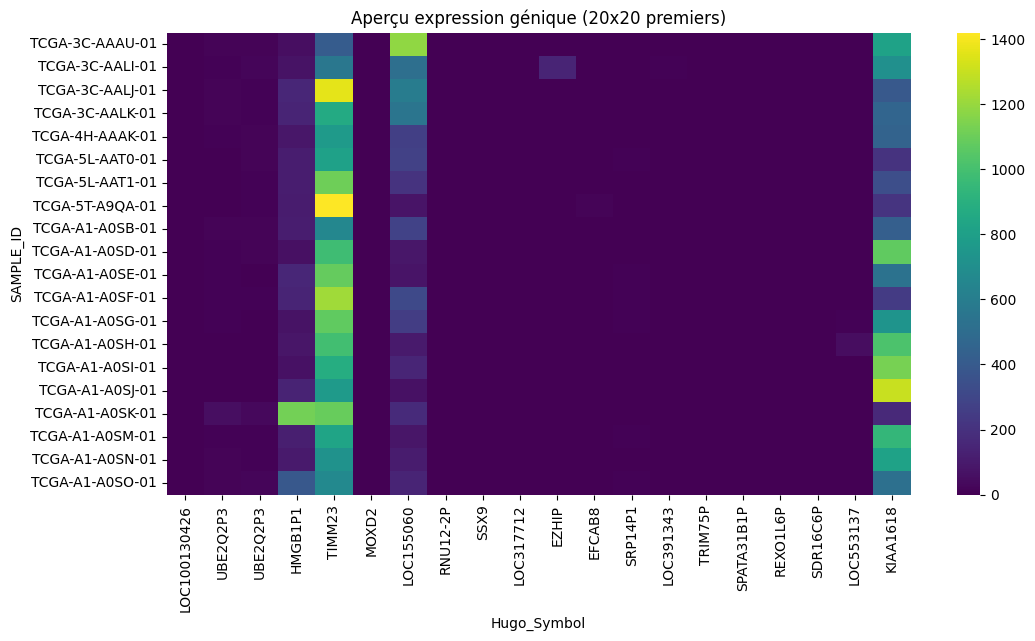

✅ Fichiers sauvegardés dans : c:\Users\nidha\Desktop\xai_clinical_prediction\data\processed


In [1]:
# Cellule 1 : Installer les dépendances puis imports


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# Cellule 2 : Chemins relatifs — fonctionne partout (WSL, Windows, Colab)
from pathlib import Path

# Le notebook est dans /notebooks/, donc le projet est le dossier parent
notebook_dir = Path.cwd()
print(f"Répertoire courant : {notebook_dir}")

# Remonter jusqu'à trouver le dossier 'data'
project_root = notebook_dir
for _ in range(5):  # max 5 niveaux
    if (project_root / 'data').exists():
        break
    project_root = project_root.parent

print(f"project_root trouvé : {project_root}")

DATA_DIR      = project_root / 'data' / 'raw' / 'brca_tcga'
PROCESSED_DIR = project_root / 'data' / 'processed'

CLINICAL_FILE = DATA_DIR / 'data_clinical_patient.txt'
MRNA_FILE     = DATA_DIR / 'data_mrna_seq_v2_rsem.txt'
MUTATION_FILE = DATA_DIR / 'data_mutations.txt'

# Vérification
print(f"\nDATA_DIR existe : {DATA_DIR.exists()}")
for path in (CLINICAL_FILE, MRNA_FILE, MUTATION_FILE):
    status = "✅" if path.exists() else "❌"
    print(f"{status} {path.name}")
    if not path.exists():
        raise FileNotFoundError(f"Introuvable : {path}")

print("\n✅ Tous les fichiers trouvés !")

# Cellule 3 : Chargement des données cliniques
clinical_df = pd.read_csv(CLINICAL_FILE, sep='\t', skiprows=4)
print(f"Données cliniques: {clinical_df.shape}")
print(clinical_df.columns.tolist())

# Cellule 4 : Variables cibles
target_variables = [
    'OS_STATUS', 'OS_MONTHS',
    'DFS_STATUS', 'DFS_MONTHS',
    'TUMOR_STAGE', 'GRADE', 'AGE',
    'ER_STATUS', 'PR_STATUS', 'HER2_STATUS',
]
# Cellule diagnostic : voir les vraies colonnes disponibles
print("Colonnes disponibles :")
for col in sorted(clinical_df.columns.tolist()):
    print(f"  '{col}'")
# Cellule 5 : Distribution des variables (robuste aux colonnes manquantes)
# Mapping nom attendu -> nom alternatif possible
col_candidates = {
    'AGE':         ['AGE', 'age', 'Age'],
    'TUMOR_STAGE': ['TUMOR_STAGE', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'STAGE',
                    'PATH_STAGE', 'CLINICAL_STAGE', 'TUMOR_STAGE_2009'],
    'OS_STATUS':   ['OS_STATUS', 'VITAL_STATUS', 'SURVIVAL_STATUS'],
}

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

age_col   = find_col(clinical_df, col_candidates['AGE'])
stage_col = find_col(clinical_df, col_candidates['TUMOR_STAGE'])
os_col    = find_col(clinical_df, col_candidates['OS_STATUS'])

print(f"Colonnes utilisées → AGE: '{age_col}' | STAGE: '{stage_col}' | OS: '{os_col}'")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

if age_col:
    clinical_df[age_col].hist(ax=axes[0, 0], bins=30)
    axes[0, 0].set_title(f"Distribution de l'âge ({age_col})")
else:
    axes[0, 0].set_title("AGE — colonne introuvable")

if stage_col:
    clinical_df[stage_col].value_counts().plot(kind='bar', ax=axes[0, 1])
    axes[0, 1].set_title(f'Stade tumoral ({stage_col})')
else:
    axes[0, 1].set_title("TUMOR_STAGE — colonne introuvable")

if os_col:
    clinical_df[os_col].value_counts().plot(kind='bar', ax=axes[0, 2])
    axes[0, 2].set_title(f'Statut de survie ({os_col})')
else:
    axes[0, 2].set_title("OS_STATUS — colonne introuvable")

# Désactiver les sous-plots vides
for ax in axes[1]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# Cellule 6 : Chargement expression génique
mrna_df = pd.read_csv(MRNA_FILE, sep='\t')
print(f"Expression génique: {mrna_df.shape}")

mrna_t = mrna_df.set_index('Hugo_Symbol').drop('Entrez_Gene_Id', axis=1).T
mrna_t.index.name = 'SAMPLE_ID'
print(f"Transposé: {mrna_t.shape}")

# Cellule 7 : Visualisation de l'expression
plt.figure(figsize=(12, 6))
sns.heatmap(mrna_t.iloc[:20, :20], cmap='viridis')
plt.title('Aperçu expression génique (20x20 premiers)')
plt.show()

# Cellule 8 : Sauvegarde
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
clinical_df.to_csv(PROCESSED_DIR / 'clinical_explored.csv', index=False)
mrna_t.to_csv(PROCESSED_DIR / 'mrna_explored.csv')
print("✅ Fichiers sauvegardés dans :", PROCESSED_DIR)